<a href="https://colab.research.google.com/github/sanvisinghal/CODSOFT/blob/main/EcosystemManagement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn nltk spacy wordcloud gensim bertopic sentence-transformers umap-learn hdbscan
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [2]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving 4.18.csv to 4.18.csv
Uploaded file: 4.18.csv


In [3]:
df = pd.read_csv(
    filename,
    encoding="utf-8-sig",
    low_memory=False
)

print("Rows and columns:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Rows and columns: (1558, 5)
Columns: ['Title', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']


,Title,Link,Abstract,Author Keywords,Index Keywords
0,Chronic C-S-Fe defense dominance over nutrient removal in nanoplastics-exposed constructed wetlands: persistent feoA as the core biomarker,https://www.scopus.com/pages/publications/105025422272?origin=resultslist,"Constructed wetlands (CWs) face intensifying threats from nanoplastics (NPs). While existing evidence confirmed NPs impaired pollutant removal by disrupting microbial metabolism, critical knowledg...",C-N-P-S-Fe cycle; Constructed wetlands; Microbial community; Nanoplastics; Pollutant removal,Biogeochemistry; Ecosystems; Environmental management; Investments; Iron compounds; Metabolism; Microorganisms; Nitrogen removal; Physiology; Pollution control; Pollution detection; Wetlands; C-N-...
1,Synergistic multi-site engineering of bound exciton relays for near-unity PLQY and stable NIR emission in lead-free perovskite inspired 0D metal halides,https://www.scopus.com/pages/publications/105040084278?origin=resultslist,Efficient near-infrared (NIR) emission in lead-free perovskite-inspired 0D metal halides remains constrained by non-radiative losses and a fundamental limitation to singular energy transfer pathwa...,0D Metal Halides; Bound Exciton; High PLQY; Lead Free Perovskites; Multi-doping; NIR Emission; Solvothermal Synthesis,Antimony compounds; Bromine compounds; Cesium compounds; Defects; Ecosystems; Energy transfer; Excited states; Excitons; Harvesting; Infrared devices; Lead compounds; Metal drawing; Niobium compou...
2,"The Fading Gulf: Morphological Transformations, Cyclone Footprints, and Land Use Dynamics Threatening Long-Term Resilience for Gulf of Mannar Coastal Islands",https://www.scopus.com/pages/publications/105045065656?origin=resultslist,"This study investigates dynamic morphological processes, cyclone-induced shoreline migrations, and land-use/land-cover (LULC) characteristics in the region of Gulf of Mannar Islands between southe...",Anthropogenic pressures; Ecological indicators; Fragile Island; Gulf of Mannar Islands; Imaging; LULC; Sensing,Anthropogenic; Biodiversity; Ecosystems; Hurricanes; Land use; Landforms; Linear regression; Satellites; Shore protection; Storms; Anthropogenic pressures; Ecological indicators; Fragile island; G...
3,HyWaThy: Hybrid modeling of nearshore Waves with different baThymetric states,https://www.scopus.com/pages/publications/105011366718?origin=resultslist,"Coastal areas such as sandy beaches are highly pressured environments by humans worldwide, as they provide a wide range of ecosystem services that directly benefit societies. The growing concentra...",Bathymetries; Hybrid methodology; Hydrodynamics; Nearshore waves; XBeach non hydrostatic,Beaches; Coastal engineering; Coastal zones; Data flow analysis; Ecosystems; Hydraulics; Hydrographic surveys; Offshore oil well production; Principal component analysis; Sediment transport; Water...
4,A Multifactor Harmonized Vegetation Index Compositing (MHVC) Approach for Monitoring Vegetation Dynamics in Sandy Land Ecosystems With Landsat-8/9 and Sentinel-2,https://www.scopus.com/pages/publications/105044371861?origin=resultslist,"ccurate monitoring of vegetation dynamics in optically complex sandy land ecosystems requires high-spatiotemporal-resolution time series, yet generating such records from individual sensors remain...",Data harmonization; Landsat-8/9; Multifactor Harmonized Vegetation index Compositing (MHVC); sandy land; Sentinel-2,China; Ordos; Aerosols; Clouds; Dust; Ecosystems; Filtration; Forestry; Landsat; Median filters; Radiometry; Reflection; Sand; Vegetation; Compositing; Data harmonization; LANDSAT; Landsat-8/9; Mu...


In [4]:
df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

required_columns = ["Title", "Abstract"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Missing required column: {column}")

text_columns = [
    "Title",
    "Abstract",
    "Author Keywords",
    "Index Keywords"
]

for column in text_columns:
    if column in df.columns:
        df[column] = df[column].fillna("").astype(str)

df = df.drop_duplicates(
    subset="Title"
).reset_index(drop=True)

df["text"] = (
    df["Title"] + " " +
    df["Abstract"] + " " +
    df.get("Author Keywords", "") + " " +
    df.get("Index Keywords", "")
)

print("Rows after removing duplicate titles:", len(df))
print("Missing values:")
display(df.isnull().sum())

Rows after removing duplicate titles: 1558
Missing values:


,0
Title,0
Link,0
Abstract,0
Author Keywords,0
Index Keywords,0
text,0


In [5]:
def extract_publication_year(text):
    text = str(text)

    # Search only the metadata at the end of the Scopus record
    metadata_tail = text[-700:]

    years = re.findall(
        r"\b(19\d{2}|20\d{2})\b",
        metadata_tail
    )

    years = [
        int(year)
        for year in years
        if 1900 <= int(year) <= 2026
    ]

    return years[-1] if years else np.nan


# Use a true year column if one exists
possible_year_columns = [
    "Year",
    "Publication Year",
    "Year Published",
    "Cover Date"
]

existing_year_column = next(
    (
        column
        for column in possible_year_columns
        if column in df.columns
    ),
    None
)

if existing_year_column:
    df["Year"] = pd.to_numeric(
        df[existing_year_column]
        .astype(str)
        .str.extract(r"\b(19\d{2}|20\d{2})\b")[0],
        errors="coerce"
    )
else:
    df["Year"] = df["text"].apply(
        extract_publication_year
    )

# Final safety rule
df.loc[
    ~df["Year"].between(1900, 2026),
    "Year"
] = np.nan

df["Year"] = df["Year"].astype("Int64")

print("Publication-year range:")
print(df["Year"].min(), "to", df["Year"].max())

print("\nYears after 2026:")
print((df["Year"] > 2026).sum())

display(
    df["Year"]
    .value_counts()
    .sort_index()
)

Publication-year range:
1994 to 2026

Years after 2026:
0


,count
Year,
1994,1
2000,1
2002,1
2011,10
2012,68
2013,53
2014,2
2016,2
2017,1


In [6]:
country_names = [
    "China", "India", "Japan", "Indonesia", "Turkey",
    "Canada", "Ghana", "Spain", "Portugal", "Taiwan",
    "Australia", "Brazil", "United States", "United Kingdom",
    "Germany", "France", "Italy", "Pakistan", "Bangladesh",
    "Malaysia", "Singapore", "Thailand", "Vietnam",
    "South Korea", "Russia", "Mexico", "South Africa",
    "Nigeria", "Iran", "Saudi Arabia", "New Zealand",
    "Netherlands", "Switzerland", "Poland", "Norway",
    "Sweden", "Finland", "Denmark", "Austria", "Belgium",
    "Greece", "Egypt", "Morocco", "Nepal", "Sri Lanka",
    "Ethiopia"
]

def extract_country(text):
    text = str(text).lower()

    for country in country_names:
        pattern = r"\b" + re.escape(country.lower()) + r"\b"

        if re.search(pattern, text):
            return country

    return "Unknown"


df["Country"] = df["text"].apply(
    extract_country
)

display(
    df["Country"]
    .value_counts()
    .head(20)
)

,count
Country,
Unknown,873
China,356
India,43
United States,38
Iran,21
Italy,17
Spain,16
Switzerland,16
Germany,16


In [7]:
import spacy

nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

custom_stopwords = {
    "study", "paper", "research", "result",
    "results", "method", "methods", "using",
    "used", "based", "show", "shows", "shown",
    "include", "including", "provide",
    "provided", "propose", "proposed",
    "aim", "aims", "find", "finding",
    "findings"
}

def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\([^)]*\)",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z0-9\s-]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    doc = nlp(text)
    tokens = []

    for token in doc:
        word = token.lemma_.lower().strip()

        if (
            len(word) > 2
            and not token.is_stop
            and not token.like_num
            and token.is_alpha
            and word not in custom_stopwords
        ):
            tokens.append(word)

    return tokens


df["tokens"] = df["text"].apply(
    preprocess_text
)

df["clean_text"] = df["tokens"].apply(
    " ".join
)

df["word_count"] = df["clean_text"].str.split().str.len()

print("Preprocessing complete.")
display(
    df[[
        "Title",
        "clean_text",
        "word_count"
    ]].head()
)

Preprocessing complete.


,Title,clean_text,word_count
0,Chronic C-S-Fe defense dominance over nutrient removal in nanoplastics-exposed constructed wetlands: persistent feoA as the core biomarker,chronic defense dominance nutrient removal nanoplastics expose construct wetland persistent feoa core biomarker construct wetland face intensify threat nanoplastic existing evidence confirm nps im...,217
1,Synergistic multi-site engineering of bound exciton relays for near-unity PLQY and stable NIR emission in lead-free perovskite inspired 0D metal halides,synergistic multi site engineering bound exciton relay near unity plqy stable nir emission lead free perovskite inspire metal halide efficient near infrared emission lead free perovskite inspire m...,300
2,"The Fading Gulf: Morphological Transformations, Cyclone Footprints, and Land Use Dynamics Threatening Long-Term Resilience for Gulf of Mannar Coastal Islands",fading gulf morphological transformation cyclone footprint land use dynamic threaten long term resilience gulf mannar coastal island investigate dynamic morphological process cyclone induce shorel...,240
3,HyWaThy: Hybrid modeling of nearshore Waves with different baThymetric states,hywathy hybrid modeling nearshore wave different bathymetric state coastal area sandy beach highly pressured environment human worldwide wide range ecosystem service directly benefit society grow ...,230
4,A Multifactor Harmonized Vegetation Index Compositing (MHVC) Approach for Monitoring Vegetation Dynamics in Sandy Land Ecosystems With Landsat-8/9 and Sentinel-2,multifactor harmonize vegetation index compositing approach monitor vegetation dynamic sandy land ecosystem ccurate monitoring vegetation dynamic optically complex sandy land ecosystem require hig...,324


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    ngram_range=(1, 2),
    max_features=10000
)

count_matrix = count_vectorizer.fit_transform(
    df["clean_text"]
)

count_terms = count_vectorizer.get_feature_names_out()

print("Count matrix:", count_matrix.shape)

Count matrix: (1558, 10000)


In [9]:
from sklearn.decomposition import LatentDirichletAllocation

topic_range = range(2, 13)

lda_models = {}
lda_perplexities = {}

for number_of_topics in topic_range:
    lda_model = LatentDirichletAllocation(
        n_components=number_of_topics,
        random_state=42,
        learning_method="batch",
        max_iter=30,
        doc_topic_prior=0.1,
        topic_word_prior=0.01
    )

    lda_model.fit(count_matrix)

    lda_models[number_of_topics] = lda_model

    lda_perplexities[number_of_topics] = (
        lda_model.perplexity(count_matrix)
    )

print("LDA models trained.")

LDA models trained.


In [10]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

dictionary = Dictionary(
    df["tokens"].tolist()
)

coherence_scores = {}

for number_of_topics, lda_model in lda_models.items():

    topic_words = []

    for topic in lda_model.components_:
        top_indices = topic.argsort()[-15:][::-1]

        words = [
            count_terms[index]
            for index in top_indices
        ]

        topic_words.append(words)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=df["tokens"].tolist(),
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence_scores[number_of_topics] = (
        coherence_model.get_coherence()
    )

coherence_table = pd.DataFrame({
    "Number_of_Topics": list(
        coherence_scores.keys()
    ),
    "Coherence": list(
        coherence_scores.values()
    ),
    "Perplexity": [
        lda_perplexities[number]
        for number in coherence_scores.keys()
    ]
})

display(coherence_table)

,Number_of_Topics,Coherence,Perplexity
0,2,0.432559,3039.916754
1,3,0.426733,2839.965495
2,4,0.450596,2751.806312
3,5,0.498940,2582.564200
4,6,0.492468,2535.916735
5,7,0.504968,2492.197188
6,8,0.515054,2439.445845
7,9,0.484171,2384.595601
8,10,0.519418,2352.849057
9,11,0.509804,2335.796160


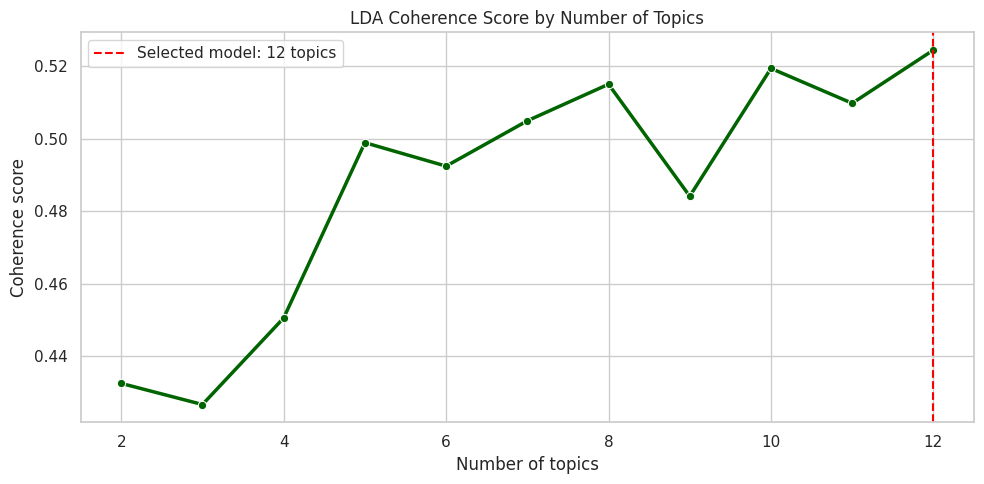

Selected number of topics: 12
Highest coherence score: 0.5245


In [11]:
best_lda_topics = int(
    coherence_table.loc[
        coherence_table["Coherence"].idxmax(),
        "Number_of_Topics"
    ]
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=coherence_table,
    x="Number_of_Topics",
    y="Coherence",
    marker="o",
    linewidth=2.5,
    color="darkgreen"
)

plt.axvline(
    best_lda_topics,
    color="red",
    linestyle="--",
    label=(
        f"Selected model: "
        f"{best_lda_topics} topics"
    )
)

plt.title(
    "LDA Coherence Score by Number of Topics"
)

plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Selected number of topics:",
    best_lda_topics
)

print(
    "Highest coherence score:",
    round(
        coherence_table["Coherence"].max(),
        4
    )
)

In [12]:
coherence_table.to_csv(
    "lda_coherence_scores_updated.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved: lda_coherence_scores_updated.csv"
)

Saved: lda_coherence_scores_updated.csv


In [13]:
best_lda_model = lda_models[
    best_lda_topics
]

lda_doc_topic_matrix = (
    best_lda_model.transform(count_matrix)
)

df["LDA_Topic"] = (
    lda_doc_topic_matrix.argmax(axis=1) + 1
)

df["LDA_Topic_Probability"] = (
    lda_doc_topic_matrix.max(axis=1)
)

print("Final LDA model applied.")

Final LDA model applied.


In [14]:
def get_topic_words(
    model,
    feature_names,
    number_of_words=15
):
    rows = []

    for topic_number, topic in enumerate(
        model.components_,
        start=1
    ):
        top_indices = topic.argsort()[
            -number_of_words:
        ][::-1]

        words = [
            feature_names[index]
            for index in top_indices
        ]

        rows.append({
            "Topic": topic_number,
            "Top_Words": ", ".join(words)
        })

    return pd.DataFrame(rows)


lda_topic_words = get_topic_words(
    best_lda_model,
    count_terms,
    number_of_words=15
)

display(lda_topic_words)

,Topic,Top_Words
0,1,"innovation, digital, technology, knowledge, model, decision, datum, system, business, base, process, development, analysis, platform, industry"
1,2,"urban, service, ecosystem service, green, sustainable, development, city, area, spatial, climate, analysis, china, sustainable development, base, planning"
2,3,"land, use, land use, change, service, forest, ecosystem service, wetland, environmental, cover, value, conservation, sustainable, model, impact"
3,4,"community, microbial, system, stability, dynamic, control, model, microbial community, interaction, effect, bifurcation, predator, functional, analysis, population"
4,5,"risk, pollution, ecological, assessment, environmental, risk assessment, health, water, wastewater, treatment, metal, source, ecological risk, chemical, high"
5,6,"model, learn, remote, machine, sense, learning, datum, remote sense, forest, deep, machine learn, network, accuracy, tree, satellite"
6,7,"system, energy, environmental, life, blockchain, base, cycle, impact, network, life cycle, cost, sustainable, security, smart, power"
7,8,"carbon, lake, nitrogen, nutrient, emission, organic, gas, phosphorus, sequestration, carbon sequestration, eutrophication, greenhouse, greenhouse gas, dissolve, matter"
8,9,"water, river, flow, basin, resource, water resource, water management, model, river basin, change, climate, groundwater, hydrological, analysis, system"
9,10,"soil, agricultural, vegetation, crop, increase, agriculture, high, yield, region, climate, forest, plant, production, water, restoration"


In [15]:
topic_labels = {
    topic: f"Topic {topic}"
    for topic in range(
        1,
        best_lda_topics + 1
    )
}

# Example:
# topic_labels = {
#     1: "Remote Sensing",
#     2: "Environmental Management",
#     3: "Climate and Ecosystems"
# }

df["LDA_Topic_Label"] = (
    df["LDA_Topic"].map(topic_labels)
)

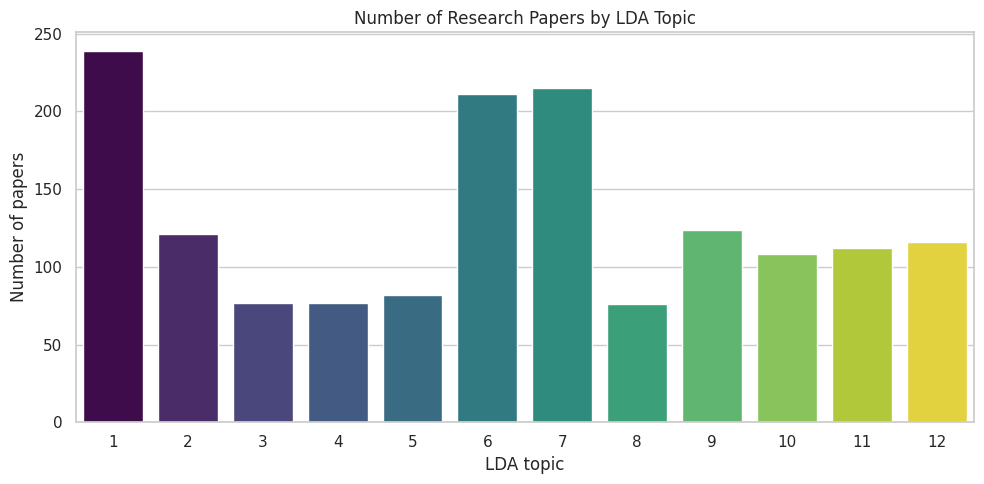

In [16]:
topic_counts = (
    df["LDA_Topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_counts.columns = [
    "Topic",
    "Number_of_Papers"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=topic_counts,
    x="Topic",
    y="Number_of_Papers",
    hue="Topic",
    palette="viridis",
    legend=False
)

plt.title(
    "Number of Research Papers by LDA Topic"
)

plt.xlabel("LDA topic")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

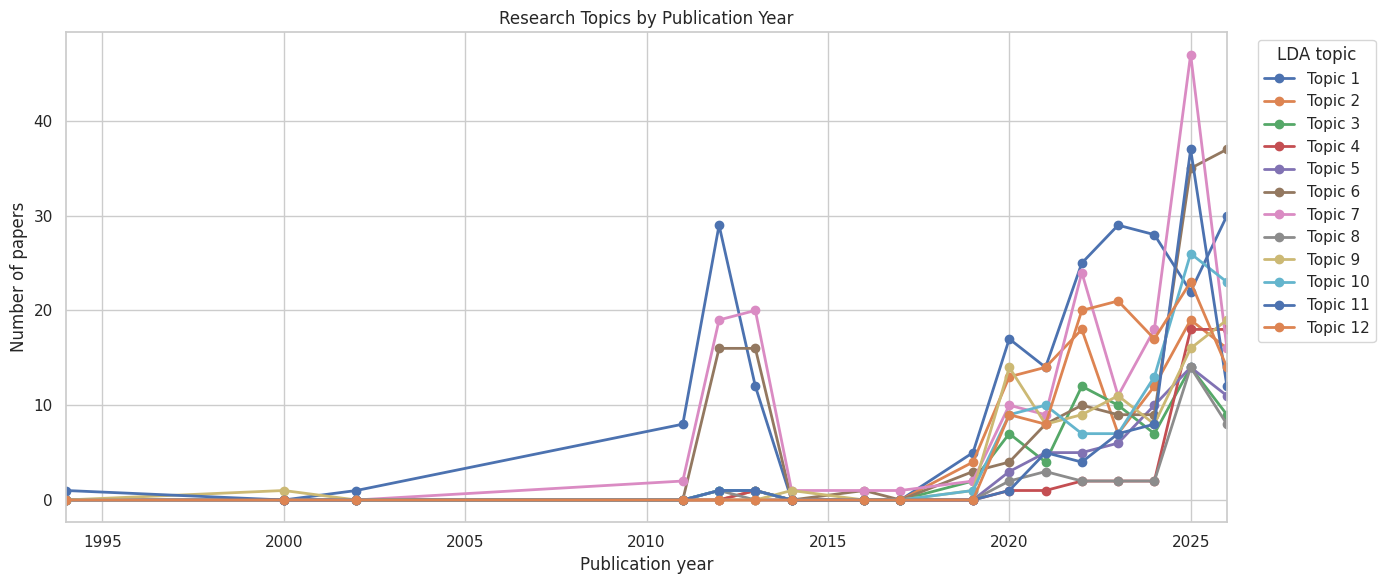

In [17]:
year_topic_data = df[
    df["Year"].notna() &
    df["Year"].between(1900, 2026)
].copy()

year_topic_data["Year"] = (
    year_topic_data["Year"].astype(int)
)

year_topic_table = pd.crosstab(
    year_topic_data["Year"],
    year_topic_data["LDA_Topic"]
).sort_index()

plt.figure(figsize=(14, 6))

for topic in year_topic_table.columns:
    plt.plot(
        year_topic_table.index,
        year_topic_table[topic],
        marker="o",
        linewidth=2,
        label=f"Topic {topic}"
    )

plt.xlim(
    year_topic_table.index.min(),
    2026
)

plt.title(
    "Research Topics by Publication Year"
)

plt.xlabel("Publication year")
plt.ylabel("Number of papers")

plt.legend(
    title="LDA topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

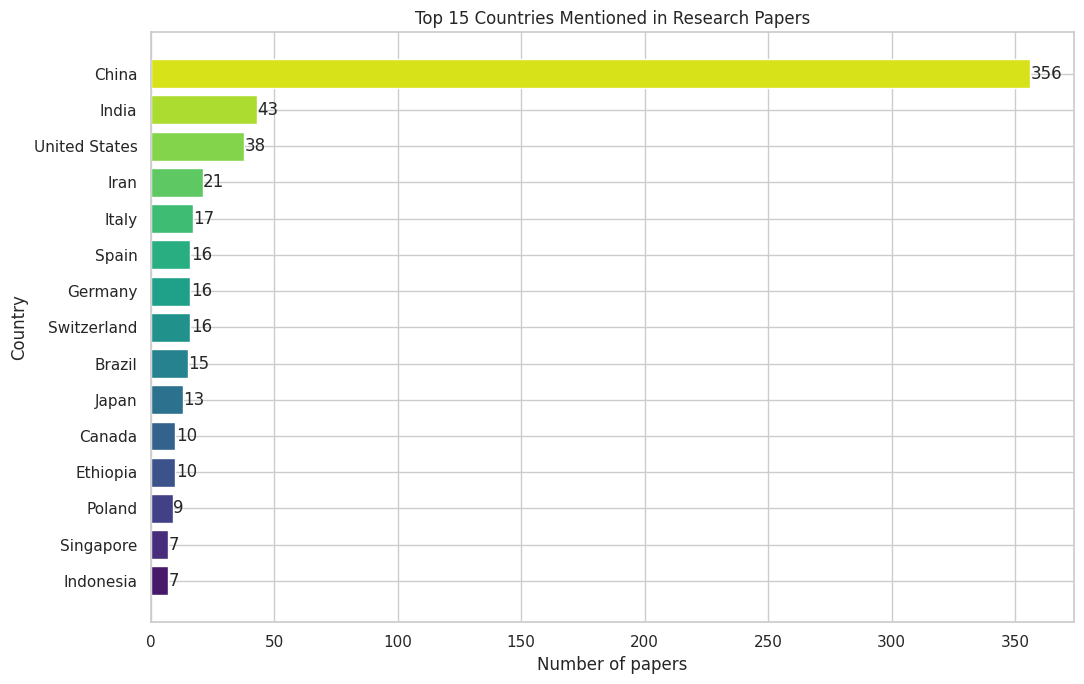

In [18]:
country_data = df[
    df["Country"] != "Unknown"
].copy()

top_countries = (
    country_data["Country"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_countries.index,
    top_countries.values,
    color=sns.color_palette(
        "viridis",
        len(top_countries)
    )
)

plt.title(
    "Top 15 Countries Mentioned in Research Papers"
)

plt.xlabel("Number of papers")
plt.ylabel("Country")

for bar in bars:
    width = int(bar.get_width())

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(width),
        va="center"
    )

plt.tight_layout()
plt.show()

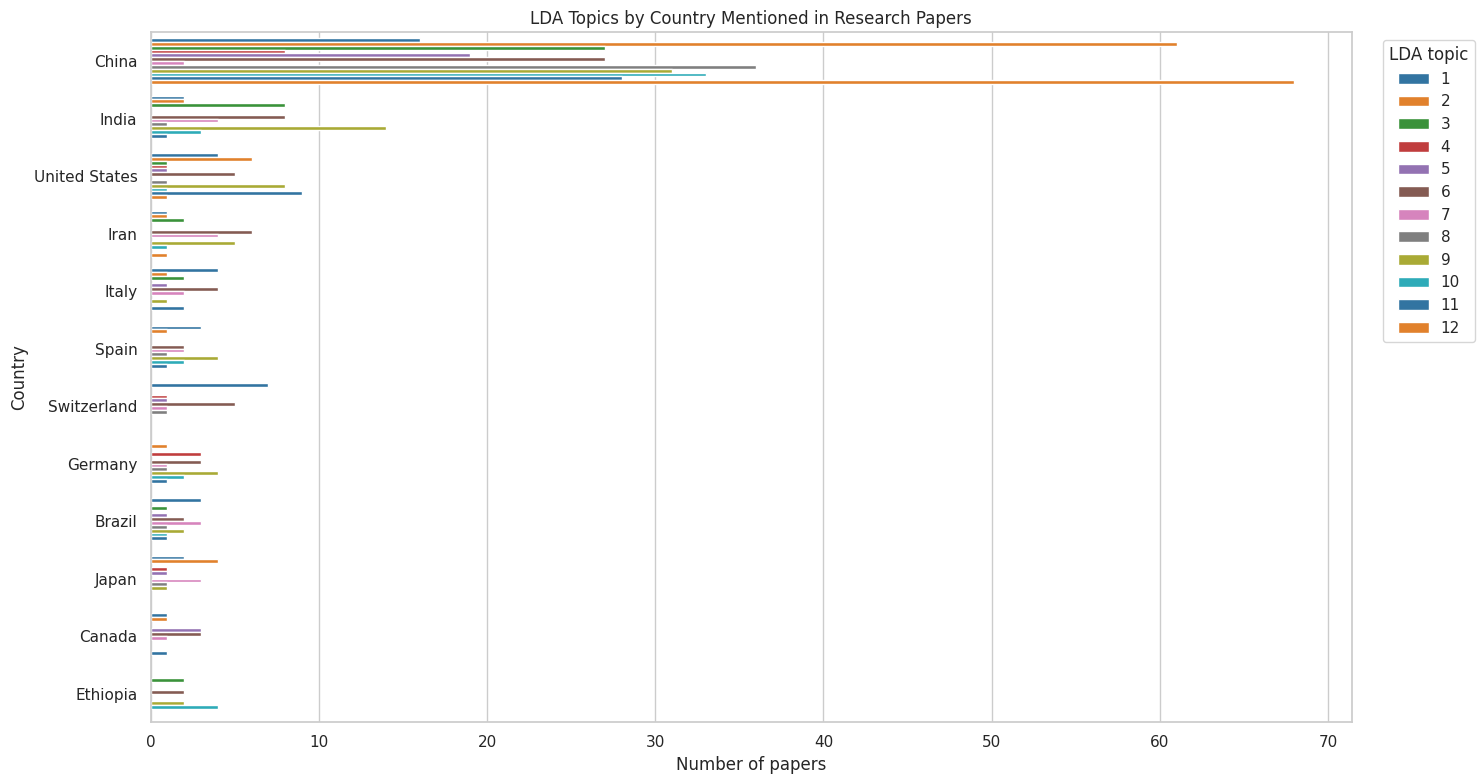

In [19]:
selected_countries = (
    country_data["Country"]
    .value_counts()
    .head(12)
    .index
)

country_topic_data = country_data[
    country_data["Country"].isin(
        selected_countries
    )
]

plt.figure(figsize=(15, 8))

sns.countplot(
    data=country_topic_data,
    y="Country",
    hue="LDA_Topic",
    order=selected_countries,
    palette="tab10"
)

plt.title(
    "LDA Topics by Country Mentioned in Research Papers"
)

plt.xlabel("Number of papers")
plt.ylabel("Country")

plt.legend(
    title="LDA topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

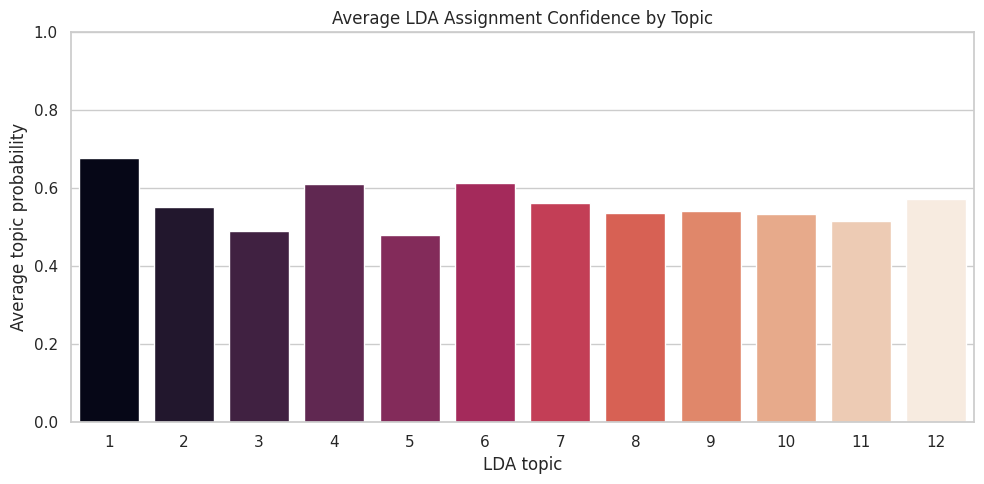

In [20]:
confidence_table = (
    df.groupby("LDA_Topic")
    ["LDA_Topic_Probability"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=confidence_table,
    x="LDA_Topic",
    y="LDA_Topic_Probability",
    hue="LDA_Topic",
    palette="rocket",
    legend=False
)

plt.title(
    "Average LDA Assignment Confidence by Topic"
)

plt.xlabel("LDA topic")
plt.ylabel("Average topic probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

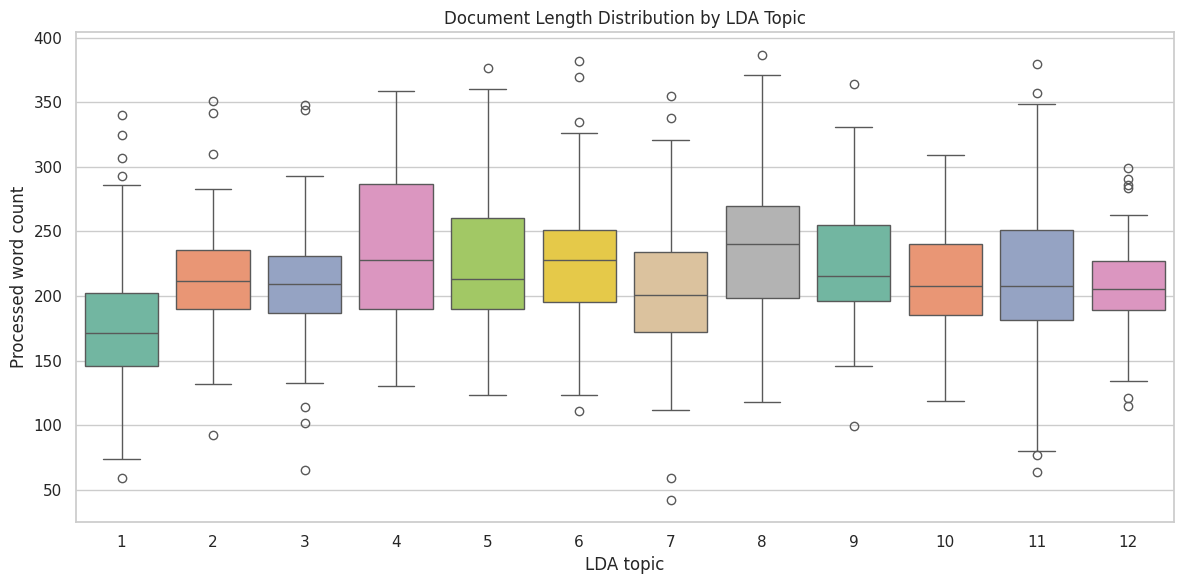

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="LDA_Topic",
    y="word_count",
    hue="LDA_Topic",
    palette="Set2",
    legend=False
)

plt.title(
    "Document Length Distribution by LDA Topic"
)

plt.xlabel("LDA topic")
plt.ylabel("Processed word count")
plt.tight_layout()
plt.show()

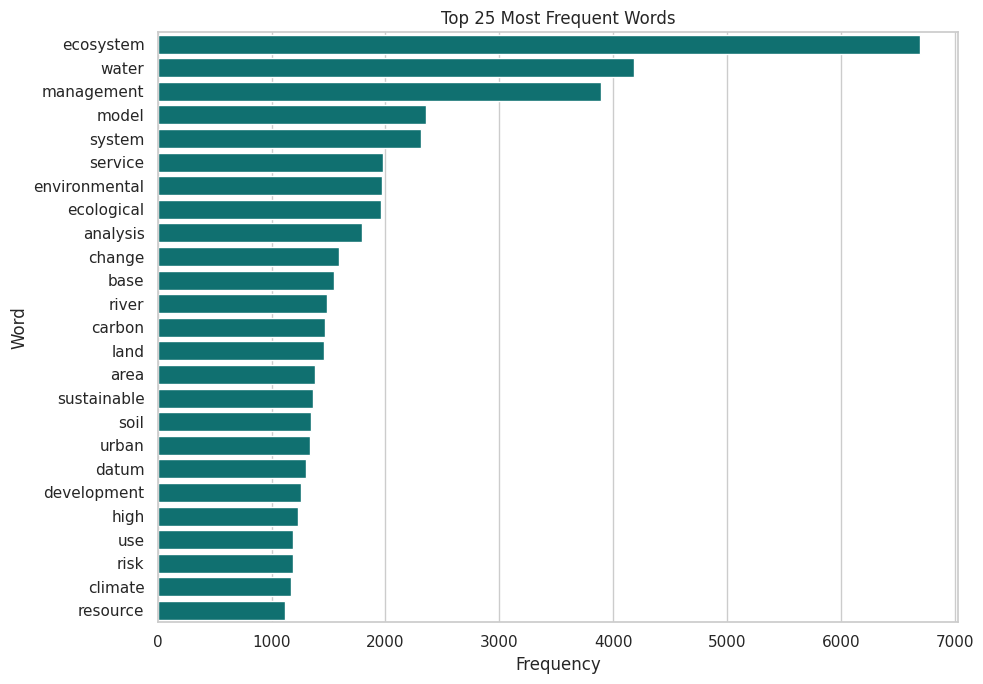

In [22]:
word_counter = Counter(
    word
    for tokens in df["tokens"]
    for word in tokens
)

top_words = pd.DataFrame(
    word_counter.most_common(25),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    y="Word",
    x="Frequency",
    color="teal"
)

plt.title(
    "Top 25 Most Frequent Words"
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

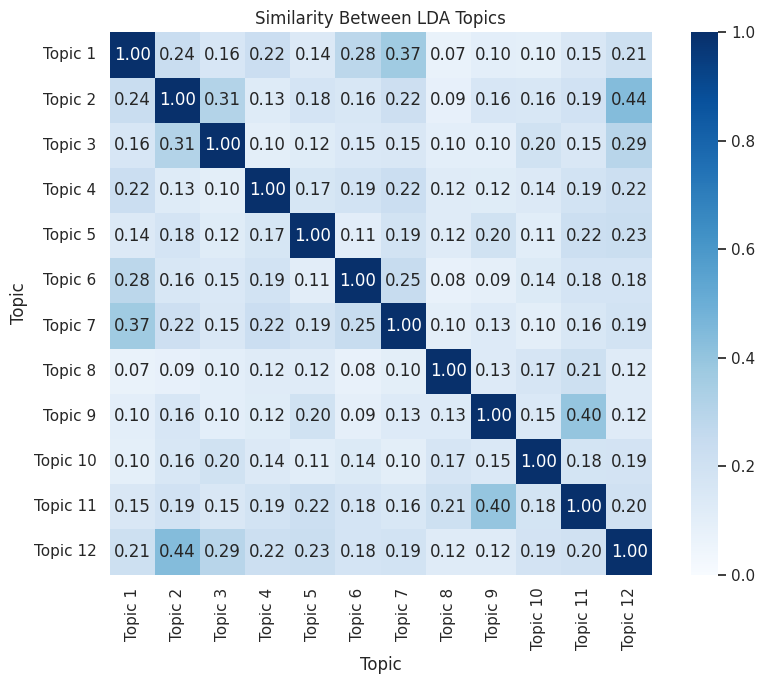

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

topic_similarity = cosine_similarity(
    best_lda_model.components_
)

topic_similarity_df = pd.DataFrame(
    topic_similarity,
    index=[
        f"Topic {i}"
        for i in range(
            1,
            best_lda_topics + 1
        )
    ],
    columns=[
        f"Topic {i}"
        for i in range(
            1,
            best_lda_topics + 1
        )
    ]
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    topic_similarity_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True
)

plt.title(
    "Similarity Between LDA Topics"
)

plt.xlabel("Topic")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

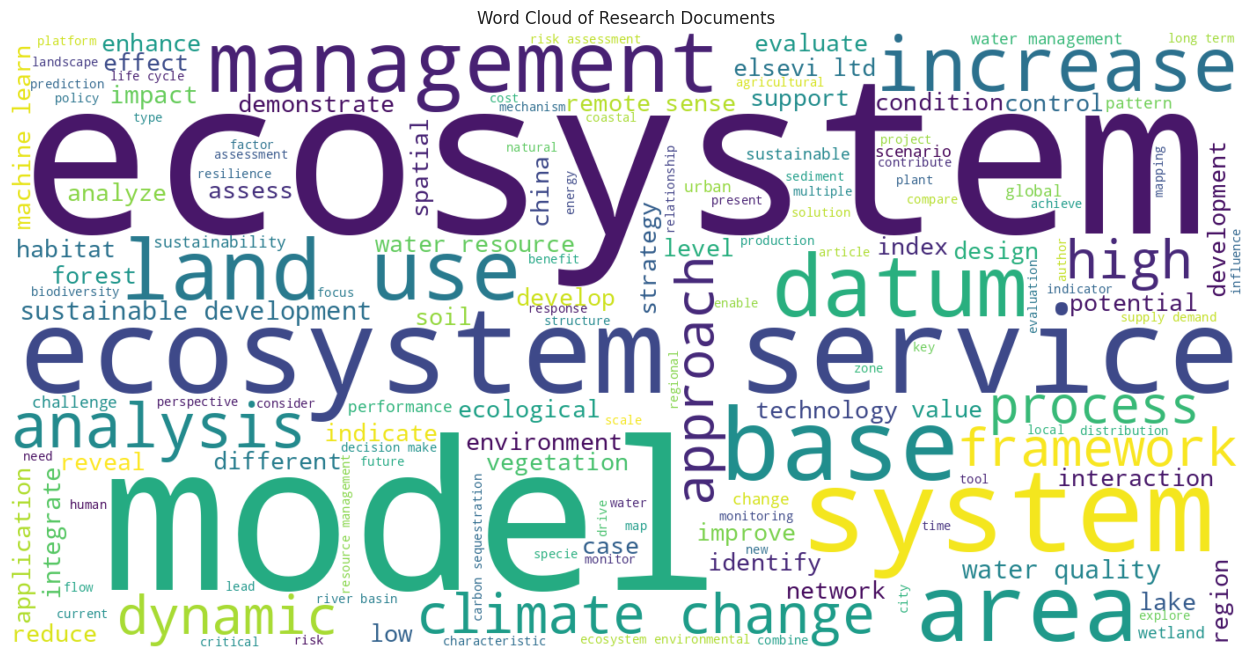

In [24]:
from wordcloud import WordCloud

all_text = " ".join(
    df["clean_text"]
)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    colormap="viridis"
).generate(all_text)

plt.figure(figsize=(16, 8))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Word Cloud of Research Documents")
plt.show()

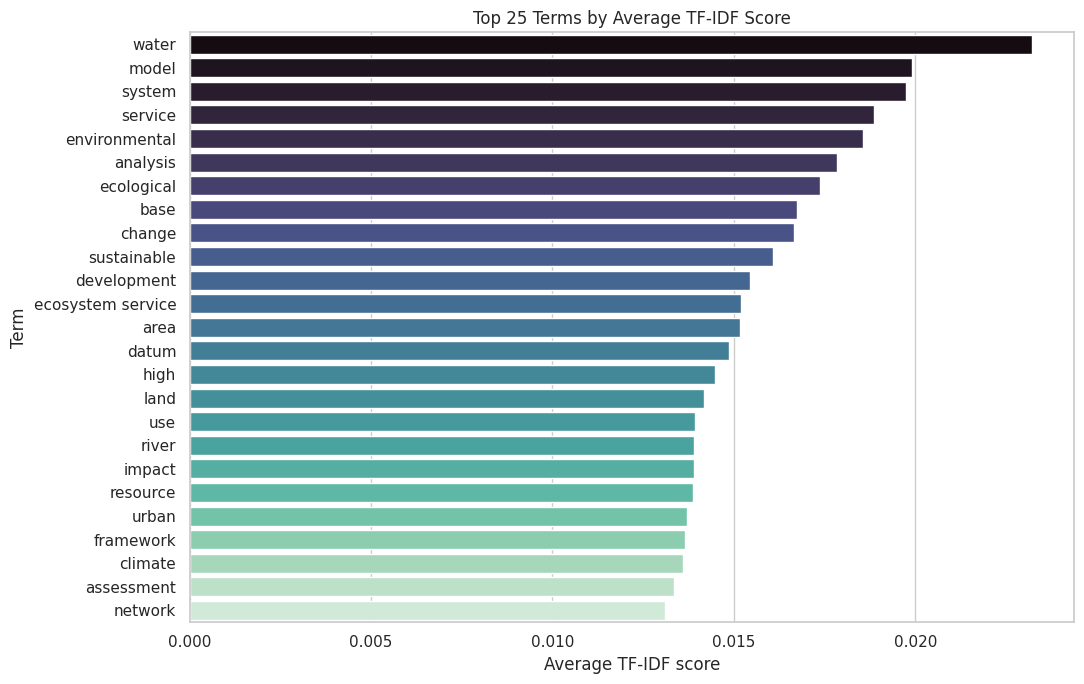

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df["clean_text"]
)

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).ravel()

tfidf_table = pd.DataFrame({
    "Term": tfidf_terms,
    "TF_IDF_Score": tfidf_scores
}).sort_values(
    "TF_IDF_Score",
    ascending=False
)

top_tfidf = tfidf_table.head(25)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_tfidf,
    x="TF_IDF_Score",
    y="Term",
    hue="Term",
    palette="mako",
    legend=False
)

plt.title("Top 25 Terms by Average TF-IDF Score")
plt.xlabel("Average TF-IDF score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

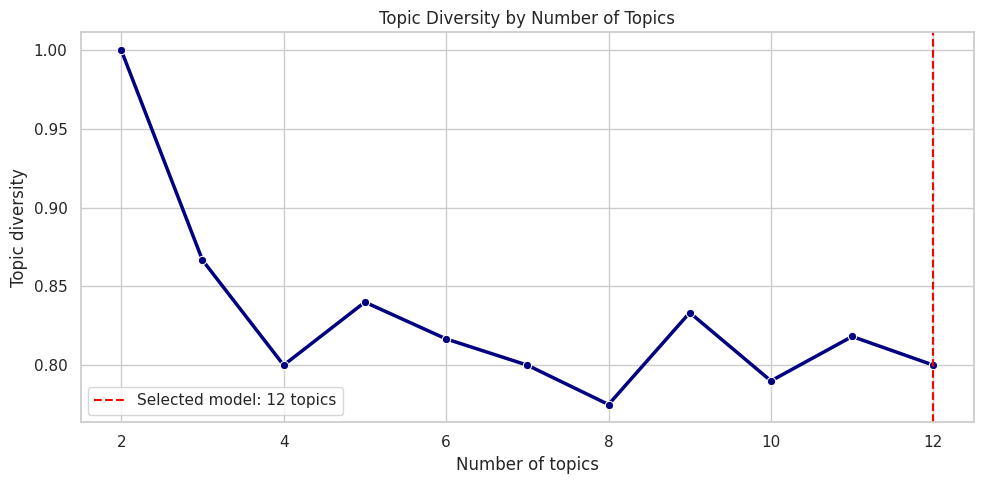

In [30]:
def calculate_topic_diversity(
    model,
    feature_names,
    top_n=10
):
    all_words = []

    for topic in model.components_:
        top_indices = topic.argsort()[
            -top_n:
        ][::-1]

        words = [
            feature_names[index]
            for index in top_indices
        ]

        all_words.extend(words)

    return len(set(all_words)) / len(all_words)


diversity_rows = []

for topic_count, lda_model in lda_models.items():
    diversity_rows.append({
        "Number_of_Topics": topic_count,
        "Topic_Diversity": calculate_topic_diversity(
            lda_model,
            count_terms,
            top_n=10
        )
    })

diversity_table = pd.DataFrame(
    diversity_rows
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=diversity_table,
    x="Number_of_Topics",
    y="Topic_Diversity",
    marker="o",
    linewidth=2.5,
    color="navy"
)

plt.axvline(
    best_lda_topics,
    color="red",
    linestyle="--",
    label=f"Selected model: {best_lda_topics} topics"
)

plt.title("Topic Diversity by Number of Topics")
plt.xlabel("Number of topics")
plt.ylabel("Topic diversity")
plt.legend()
plt.tight_layout()
plt.show()

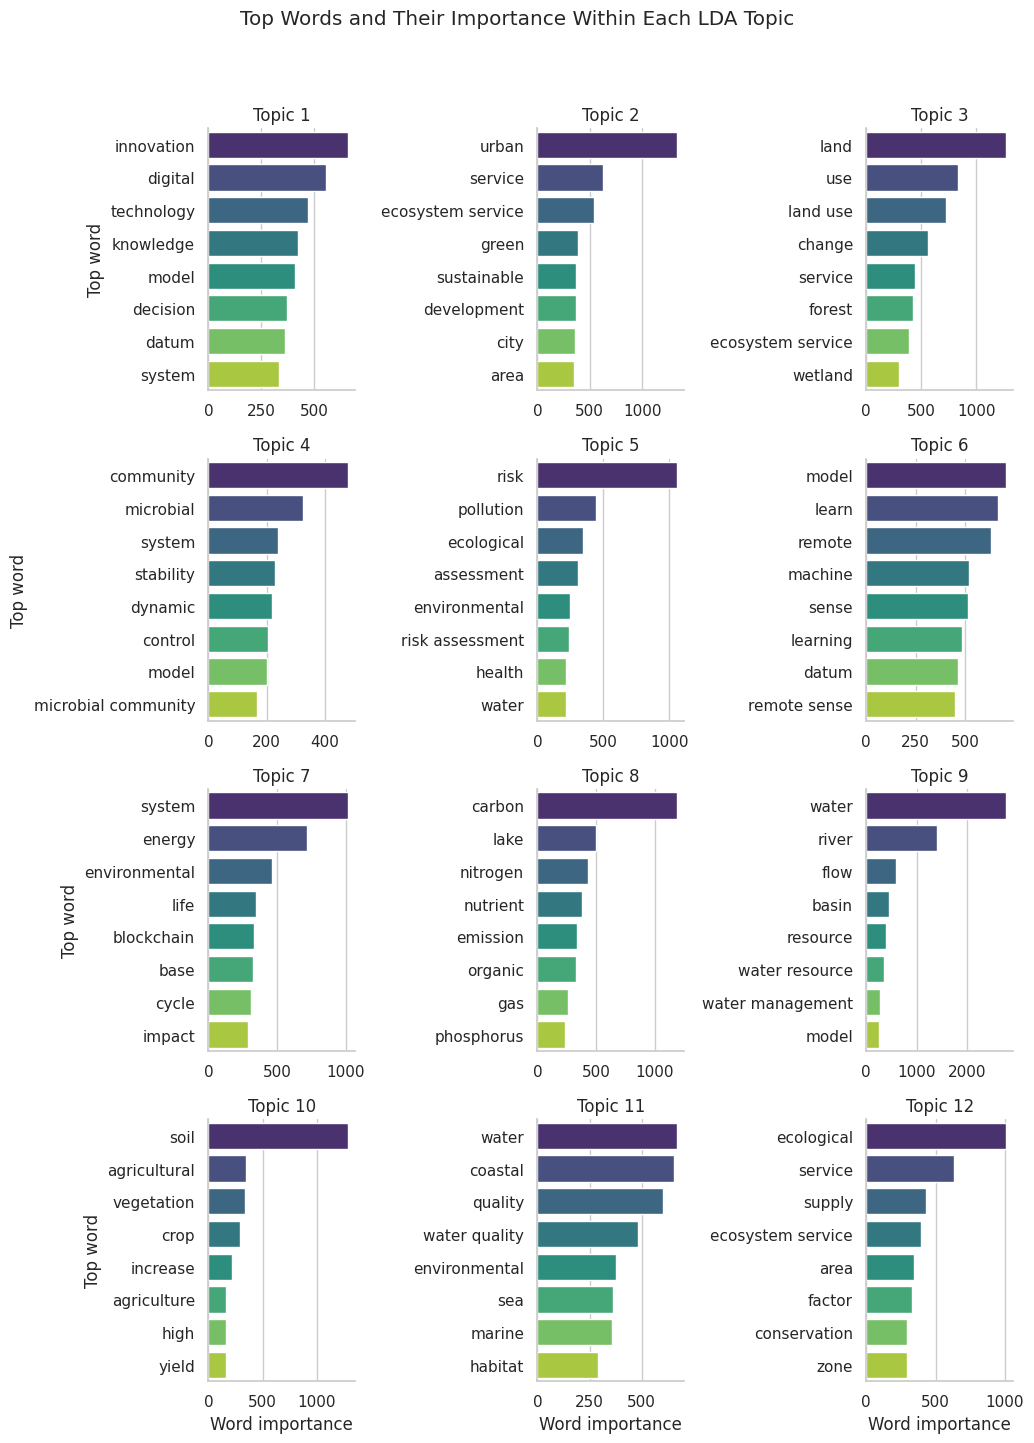

In [34]:
top_words_per_topic = 8

topic_word_rows = []

for topic_number, topic_values in enumerate(
    best_lda_model.components_,
    start=1
):
    top_indices = topic_values.argsort()[
        -top_words_per_topic:
    ][::-1]

    for rank, index in enumerate(
        top_indices,
        start=1
    ):
        topic_word_rows.append({
            "Topic": f"Topic {topic_number}",
            "Word": count_terms[index],
            "Importance": topic_values[index],
            "Rank": rank
        })

topic_word_plot_data = pd.DataFrame(
    topic_word_rows
)

g = sns.FacetGrid(
    topic_word_plot_data,
    col="Topic",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.5
)

g.map_dataframe(
    sns.barplot,
    x="Importance",
    y="Word",
    hue="Word",
    palette="viridis",
    legend=False
)

g.set_titles("{col_name}")
g.set_axis_labels(
    "Word importance",
    "Top word"
)

g.fig.suptitle(
    "Top Words and Their Importance Within Each LDA Topic",
    y=1.03
)

plt.tight_layout()
plt.show()

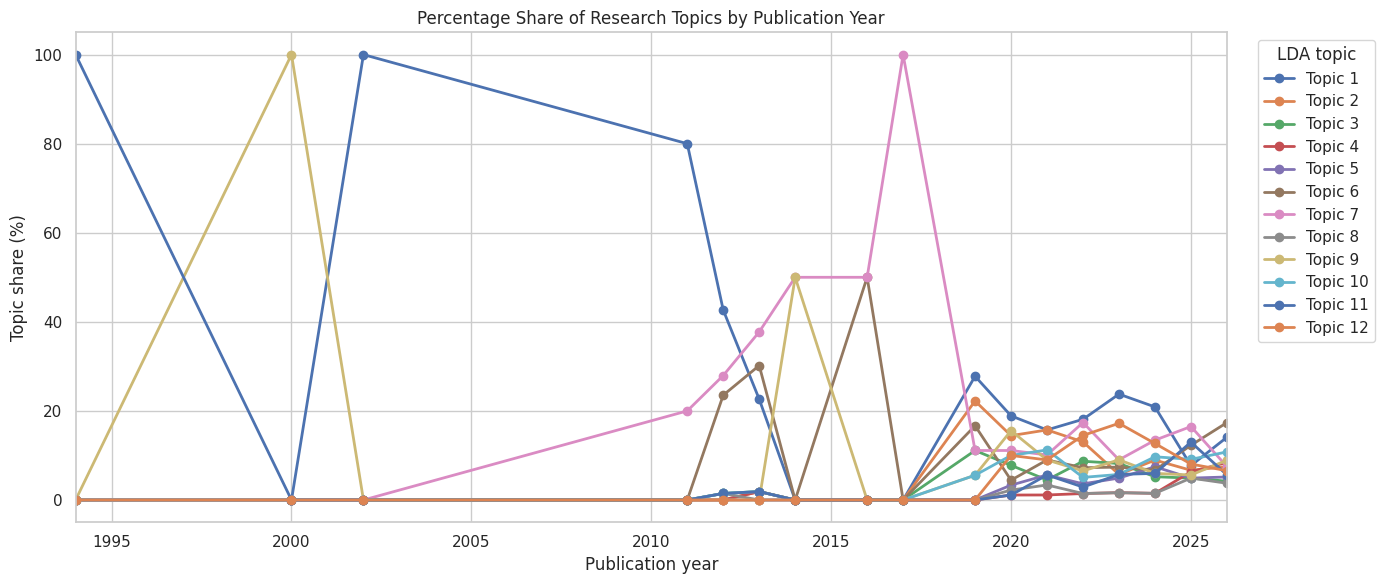

In [32]:
year_topic_data = df[
    df["Year"].notna() &
    df["Year"].between(1900, 2026)
].copy()

year_topic_data["Year"] = (
    year_topic_data["Year"].astype(int)
)

year_topic_table = pd.crosstab(
    year_topic_data["Year"],
    year_topic_data["LDA_Topic"]
).sort_index()

year_topic_percentage = (
    year_topic_table.div(
        year_topic_table.sum(axis=1),
        axis=0
    ) * 100
)

plt.figure(figsize=(14, 6))

for topic in year_topic_percentage.columns:
    plt.plot(
        year_topic_percentage.index,
        year_topic_percentage[topic],
        marker="o",
        linewidth=2,
        label=f"Topic {topic}"
    )

plt.xlim(
    year_topic_percentage.index.min(),
    2026
)

plt.title(
    "Percentage Share of Research Topics by Publication Year"
)

plt.xlabel("Publication year")
plt.ylabel("Topic share (%)")

plt.legend(
    title="LDA topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

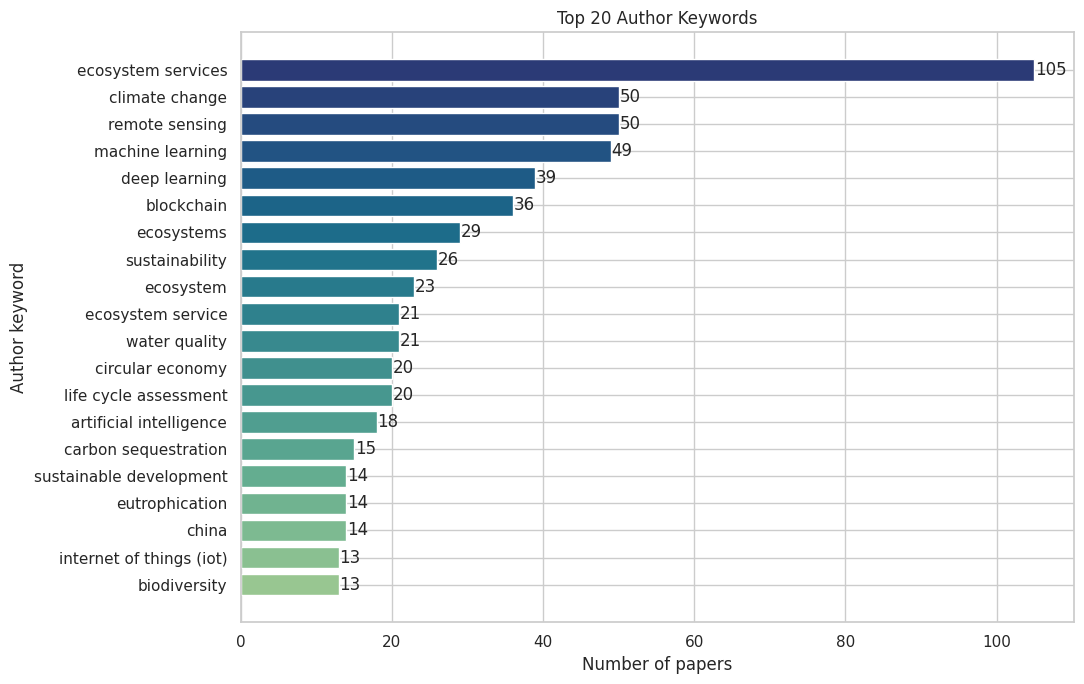

In [33]:
from collections import Counter

author_keyword_counter = Counter()

if "Author Keywords" in df.columns:
    for keyword_text in df["Author Keywords"].fillna(""):
        keywords = re.split(r"[;,]", str(keyword_text))

        for keyword in keywords:
            keyword = keyword.strip().lower()

            if keyword and len(keyword) > 1:
                author_keyword_counter[keyword] += 1

top_author_keywords = pd.DataFrame(
    author_keyword_counter.most_common(20),
    columns=["Keyword", "Frequency"]
).sort_values(
    "Frequency",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_author_keywords["Keyword"],
    top_author_keywords["Frequency"],
    color=sns.color_palette(
        "crest",
        len(top_author_keywords)
    )
)

plt.title("Top 20 Author Keywords")
plt.xlabel("Number of papers")
plt.ylabel("Author keyword")

for bar in bars:
    value = int(bar.get_width())

    plt.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

In [25]:
from sentence_transformers import SentenceTransformer

bertopic_documents = (
    df["Title"] + ". " + df["Abstract"]
).tolist()

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = embedding_model.encode(
    bertopic_documents,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Embedding shape: (1558, 384)


In [26]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=max(
        5,
        min(15, len(df) // 50)
    ),
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

bertopic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    min_topic_size=max(
        5,
        min(15, len(df) // 50)
    ),
    verbose=True
)

bertopic_topics, bertopic_probabilities = (
    bertopic_model.fit_transform(
        bertopic_documents,
        embeddings
    )
)

df["BERTopic"] = bertopic_topics

display(
    bertopic_model.get_topic_info()
)

2026-09-17 16:38:36,980 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-17 16:39:03,699 - BERTopic - Dimensionality - Completed ✓
2026-09-17 16:39:03,701 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-17 16:39:03,807 - BERTopic - Cluster - Completed ✓
2026-09-17 16:39:03,812 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-17 16:39:04,698 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,1201,0_water_ecosystem_management_study,"[water, ecosystem, management, study, ecological, environmental, land, based, model, results]","[Response of multiple mountain ecosystem services on environmental gradients: How to respond, and where should be priority conservation?. As an important part of terrestrial ecosystem and the most..."
1,1,328,1_ecosystem_innovation_digital_data,"[ecosystem, innovation, digital, data, management, based, research, ecosystems, iot, technology]",[AI and Web3 in sustainable development: a quadruple helix approach to reshaping regional innovation and startup ecosystems in China. This study addresses a critical gap in the literature on susta...
2,2,29,2_predator_prey_bifurcation_dynamics,"[predator, prey, bifurcation, dynamics, stability, model, wind, harvesting, population, control]","[Dynamical Analysis of A Predator-Prey Model Incorporating Allee Effect and Mutual Interference Between Predators. In this paper, we put forward and study a modified Leslie-Gower predator-prey mod..."


In [28]:
fig = bertopic_model.visualize_barchart(
    top_n_topics=12,
    n_words=10
)

fig.show()
fig = bertopic_model.visualize_topics()
fig.show()

In [35]:
result_columns = [
    "Title",
    "Link",
    "Abstract",
    "Author Keywords",
    "Index Keywords",
    "Year",
    "Country",
    "LDA_Topic",
    "LDA_Topic_Label",
    "LDA_Topic_Probability",
    "BERTopic"
]

available_columns = [
    column
    for column in result_columns
    if column in df.columns
]

df[available_columns].to_csv(
    "topic_modelling_results_updated.csv",
    index=False,
    encoding="utf-8-sig"
)

lda_topic_words.to_csv(
    "lda_topic_words_updated.csv",
    index=False,
    encoding="utf-8-sig"
)

coherence_table.to_csv(
    "lda_coherence_scores_updated.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Three updated files created:")
print("1. topic_modelling_results_updated.csv")
print("2. lda_topic_words_updated.csv")
print("3. lda_coherence_scores_updated.csv")

Three updated files created:
1. topic_modelling_results_updated.csv
2. lda_topic_words_updated.csv
3. lda_coherence_scores_updated.csv
